信号统计:
|    |   Signal |
|---:|---------:|
|  0 |      250 |

最近交易信号:
Empty DataFrame
Columns: [Close, Signal]
Index: []


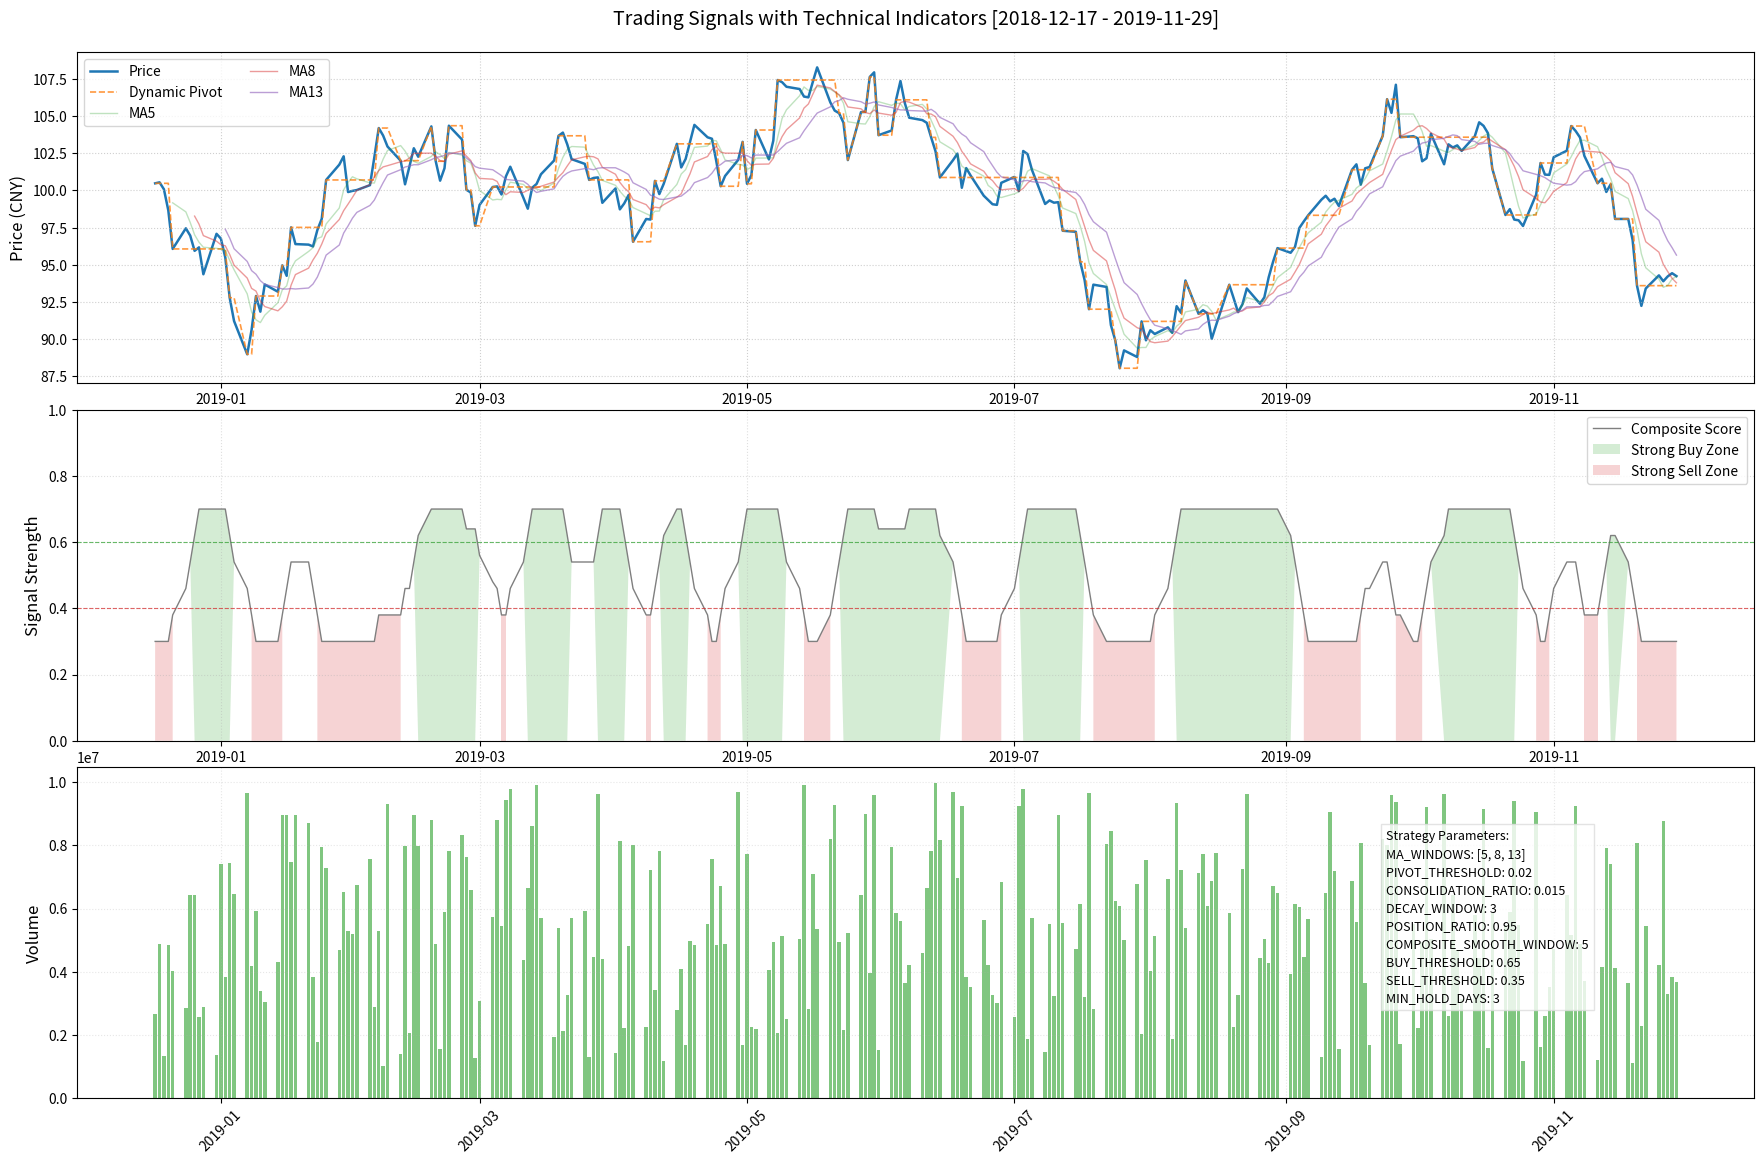

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ================ 全局参数 ================
PARAMS = {
    'MA_WINDOWS': [5, 8, 13],
    'PIVOT_THRESHOLD': 0.02,
    'CONSOLIDATION_RATIO': 0.015,
    'DECAY_WINDOW': 3,
    'POSITION_RATIO': 0.95,
    'COMPOSITE_SMOOTH_WINDOW': 5,  # 增大平滑窗口
    'BUY_THRESHOLD': 0.65,        # 提高买入阈值
    'SELL_THRESHOLD': 0.35,       # 降低卖出阈值
    'MIN_HOLD_DAYS': 3            # 新增最小持仓天数
}

# ================ 核心函数 ================
def calculate_pivot_system(close_series):
    """动态中枢系统（兼容Series和ndarray）"""
    if isinstance(close_series, pd.Series):
        close_values = close_series.values
    else:
        close_values = close_series
    
    pivots = [close_values[0]]
    current_pivot = close_values[0]
    
    for price in close_values[1:]:
        deviation = abs(price - current_pivot) / current_pivot
        if deviation > PARAMS['PIVOT_THRESHOLD']:
            current_pivot = price
        pivots.append(current_pivot)
    
    return pd.Series(pivots, index=close_series.index) if isinstance(close_series, pd.Series) else np.array(pivots)

def generate_signals(df):
    # 确保输入为DataFrame
    df = pd.DataFrame(df).copy()
    df = df.rename(columns={'close': 'Close'})
    
    # 计算均线系统
    for w in PARAMS['MA_WINDOWS']:
        df[f'MA{w}'] = df['Close'].rolling(w).mean()
    
    # 中枢系统（返回Series保证后续操作）
    df['Pivot'] = calculate_pivot_system(df['Close'])
    
    # 均线粘合检测
    ma_columns = [f'MA{w}' for w in PARAMS['MA_WINDOWS']]
    df['MA_Spread'] = df[ma_columns].max(axis=1) - df[ma_columns].min(axis=1)
    df['Consolidation'] = (df['MA_Spread'] / df['Close'] < PARAMS['CONSOLIDATION_RATIO']).astype(int)
    
    # 均线交叉系统
    df['MA5_MA8'] = df['MA5'] - df['MA8']
    df['MA8_MA13'] = df['MA8'] - df['MA13']
    df['Crossover'] = np.select(
        [
            (df['MA5_MA8'] > 0) & (df['MA8_MA13'] > 0) & 
            (df['MA5_MA8'].shift(1) <= 0) & (df['MA8_MA13'].shift(1) <= 0),
            (df['MA5_MA8'] < 0) & (df['MA8_MA13'] < 0) & 
            (df['MA5_MA8'].shift(1) >= 0) & (df['MA8_MA13'].shift(1) >= 0)
        ],
        [1, -1],
        default=0
    )
    
    # 趋势衰减检测（增强鲁棒性）
    df['Pivot_Change'] = df['Pivot'].diff()
    
    # 使用中间布尔列避免类型错误
    decay_condition = df['Pivot_Change'].rolling(PARAMS['DECAY_WINDOW']).apply(
        lambda x: (x.diff().iloc[1:] < 0).all() if len(x.dropna()) >= 2 else False,
        raw=False
    )
    
    # 分步处理空值
    df['Decay'] = decay_condition.where(decay_condition.notna(), False).astype(bool)
    df['Decay'] = df['Decay'].astype(int)  # 安全转换为整数
    
    
    
     # 动态权重分配（示例参数，可根据策略调整）
    df['Composite'] = (
        0.4 * df['Consolidation'] + 
        0.3 * df['Crossover'].abs() +  # 交叉强度
        0.3 * (1 - df['Decay'])       # 趋势持续性
    ).clip(0, 1)  # 确保在0-1区间

    # 平滑处理
    df['Composite'] = df['Composite'].rolling(
        window=PARAMS.get('COMPOSITE_SMOOTH_WINDOW', 3),
        min_periods=1
    ).mean()
    
    # 生成最终信号
    raw_buy = (df['Consolidation'] == 1) & (df['Crossover'] == 1)
    raw_sell = (df['Decay'] == 1) & (df['Crossover'] == -1)

    # 复合信号过滤
    df['Signal'] = 0
    df.loc[(raw_buy) & (df['Composite'] >= PARAMS['BUY_THRESHOLD']), 'Signal'] = 1
    df.loc[(raw_sell) & (df['Composite'] <= PARAMS['SELL_THRESHOLD']), 'Signal'] = -1

    # 增加确认机制（需连续2日满足条件）
    df['Signal'] = df['Signal'].replace(0, np.nan).ffill(limit=1).fillna(0).astype(int)

    return df

# ================ 可视化优化 ================
def plot_signals(df):
    plt.figure(figsize=(18, 12))
    
    # ===== 价格主图 =====
    ax1 = plt.subplot(311)
    price_line = ax1.plot(df['Close'], label='Price', color='#1f77b4', linewidth=1.8, zorder=1)
    
    # 动态中枢系统
    pivot_line = ax1.plot(df['Pivot'], '--', label='Dynamic Pivot', 
                        color='#ff7f0e', alpha=0.8, linewidth=1.2)
    
    # 均线系统透明度渐变
    ma_colors = ['#2ca02c', '#d62728', '#9467bd']  # 对应5/8/13日均线
    for idx, w in enumerate(PARAMS['MA_WINDOWS']):
        alpha = 0.3 + 0.5 * (idx/len(PARAMS['MA_WINDOWS']))
        ax1.plot(df[f'MA{w}'], color=ma_colors[idx], 
                alpha=alpha, linewidth=1.0, label=f'MA{w}')

    # 买卖信号增强显示
    buy_signals = df[df['Signal'] == 1]
    sell_signals = df[df['Signal'] == -1]
    if not buy_signals.empty:
        ax1.scatter(buy_signals.index, buy_signals['Close']*0.985,  # 留出标注空间
                    marker='^', color='#17becf', s=180, 
                    edgecolors='k', linewidth=1.2, zorder=5,
                    label='Buy Signal')
        for idx, row in buy_signals.iterrows():
            ax1.text(idx, row['Close']*0.975, 'B', 
                    ha='center', va='top', color='#2ca02c',
                    fontsize=10, weight='bold')
    
    if not sell_signals.empty:
        ax1.scatter(sell_signals.index, sell_signals['Close']*1.015,
                    marker='v', color='#e377c2', s=180,
                    edgecolors='k', linewidth=1.2, zorder=5,
                    label='Sell Signal')
        for idx, row in sell_signals.iterrows():
            ax1.text(idx, row['Close']*1.025, 'S', 
                    ha='center', va='bottom', color='#d62728',
                    fontsize=10, weight='bold')

    # 技术指标标注
    ax1.set_title(f'Trading Signals with Technical Indicators [{df.index[0].date()} - {df.index[-1].date()}]', 
                fontsize=14, pad=20)
    ax1.legend(loc='upper left', ncol=2)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.set_ylabel('Price (CNY)', fontsize=12)

    # ===== 信号强度子图 =====
    ax2 = plt.subplot(312, sharex=ax1)
    # 复合信号强度
    ax2.plot(df['Composite'], color='#7f7f7f', linewidth=1.0, label='Composite Score')
    ax2.fill_between(df.index, df['Composite'], 
                    where=(df['Composite'] >= 0.6),
                    facecolor='#2ca02c', alpha=0.2, interpolate=True,
                    label='Strong Buy Zone')
    ax2.fill_between(df.index, df['Composite'], 
                    where=(df['Composite'] <= 0.4),
                    facecolor='#d62728', alpha=0.2, interpolate=True,
                    label='Strong Sell Zone')
    # 动态阈值线
    ax2.axhline(0.6, color='#2ca02c', linestyle='--', alpha=0.7, linewidth=0.8)
    ax2.axhline(0.4, color='#d62728', linestyle='--', alpha=0.7, linewidth=0.8)
    ax2.set_ylabel('Signal Strength', fontsize=12)
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle=':', alpha=0.4)
    ax2.set_ylim(0, 1)

    # ===== 成交量子图 ===== （新增）
    ax3 = plt.subplot(313, sharex=ax1)
    vol_colors = ['#2ca02c' if cl > op else '#d62728' 
                for cl, op in zip(df['Close'], df['open'])]
    ax3.bar(df.index, df['volume'], color=vol_colors, alpha=0.6, width=0.8)
    ax3.set_ylabel('Volume', fontsize=12)
    ax3.grid(True, linestyle=':', alpha=0.3)
    
    # 设置x轴格式
    plt.xticks(rotation=45)
    plt.tight_layout(pad=2.0)
    plt.subplots_adjust(hspace=0.08)  # 调整子图间距
    
    # 添加策略参数标注
    param_text = '\n'.join([f'{k}: {v}' for k, v in PARAMS.items()])
    plt.figtext(0.78, 0.15, f'Strategy Parameters:\n{param_text}',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='#dddddd'),
                fontsize=9, linespacing=1.5)
    
    plt.show()


# ================ 执行入口 ================
if __name__ == '__main__':
    # 获取数据
    data = get_price(
        securities='300033.SZ',
        end_date='2019-12-01',
        fre_step='1d',
        fields=['open','high','low','close','volume'],
        fq='pre',
        bar_count=250,
        skip_paused=True
    )
    
    # 生成信号
    df = generate_signals(data)
    
    # 结果分析
    print("="*40)
    print("信号统计:")
    print(df['Signal'].value_counts().to_markdown())
    print("\n最近交易信号:")
    print(df[df['Signal'] != 0].tail(5)[['Close', 'Signal']])
    
    # 可视化
    plot_signals(df)